# Лабораторная работа №4
## Поиск ассоциативных правил в транзакционных данных



In [ ]:
import pandas as pd
import numpy as np
import random
import time
from datetime import datetime
from collections import defaultdict, Counter
from itertools import combinations, chain
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
import warnings
warnings.filterwarnings('ignore')

plt.style.use('ggplot')
sns.set_style("whitegrid")
%matplotlib inline

print(" Все библиотеки загружены успешно")

 Все библиотеки загружены успешно


In [ ]:
print("Генерация датасета о вооружениях...")

np.random.seed(42)
random.seed(42)

weapon_categories = {
    'Танки': ['Т-54/55', 'Т-62', 'Т-64', 'Т-72', 'Т-80', 'Т-90', 'Армата'],
    'БМП/БТР': ['БМП-1', 'БМП-2', 'БМП-3', 'БТР-60', 'БТР-70', 'БТР-80', 'БТР-82', 'БТР-90'],
    'Артиллерия': ['2С1 Гвоздика', '2С3 Акация', '2С19 Мста-С', '2С35 Коалиция', 'Град', 'Ураган', 'Смерч', 'Торнадо'],
    'Авиация': ['МиГ-29', 'МиГ-31', 'Су-27', 'Су-30', 'Су-34', 'Су-35', 'Су-57', 'Ту-95', 'Ту-160'],
    'Вертолеты': ['Ми-8', 'Ми-24', 'Ми-28', 'Ка-52', 'Ми-26'],
    'ПВО': ['С-300', 'С-400', 'С-500', 'Бук', 'Тор', 'Панцирь-С1', 'Оса'],
    'Флот': ['Крейсер', 'Эсминец', 'Фрегат', 'Корвет', 'Подлодка', 'Авианосец'],
    'Стрелковое': ['АК-74', 'АК-12', 'ПКМ', 'СВД', 'Винторез', 'Вал']
}

years = list(range(1945, 2026))
countries = ['СССР', 'Россия', 'Украина', 'Беларусь']
statuses = ['На вооружении', 'На хранении', 'Снят с вооружения', 'Опытный', 'В разработке']

def generate_cost(category):
    costs = {
        'Танки': (1, 8), 'БМП/БТР': (0.5, 3), 'Артиллерия': (0.3, 10),
        'Авиация': (15, 100), 'Вертолеты': (5, 30), 'ПВО': (10, 200),
        'Флот': (100, 5000), 'Стрелковое': (0.001, 0.01)
    }
    min_c, max_c = costs.get(category, (1, 10))
    return round(random.uniform(min_c, max_c), 2)

def generate_weight(category):
    weights = {
        'Танки': (30, 60), 'БМП/БТР': (10, 25), 'Артиллерия': (5, 50),
        'Авиация': (10, 200), 'Вертолеты': (5, 40), 'ПВО': (10, 100),
        'Флот': (1000, 50000), 'Стрелковое': (0.003, 0.02)
    }
    min_w, max_w = weights.get(category, (1, 10))
    return round(random.uniform(min_w, max_w), 2)

def generate_range(category):
    ranges = {
        'Танки': (300, 600), 'БМП/БТР': (400, 800), 'Артиллерия': (5, 100),
        'Авиация': (1000, 8000), 'Вертолеты': (400, 1500), 'ПВО': (10, 600),
        'Флот': (5000, 20000), 'Стрелковое': (0.3, 2)
    }
    min_r, max_r = ranges.get(category, (10, 100))
    return round(random.uniform(min_r, max_r), 1)

def generate_speed(category):
    speeds = {
        'Танки': (40, 70), 'БМП/БТР': (60, 100), 'Артиллерия': (30, 80),
        'Авиация': (800, 2500), 'Вертолеты': (200, 350), 'ПВО': (50, 100),
        'Флот': (30, 60), 'Стрелковое': (0, 0)
    }
    min_s, max_s = speeds.get(category, (10, 50))
    return random.randint(min_s, max_s)

def generate_crew(category):
    crews = {
        'Танки': (3, 4), 'БМП/БТР': (3, 10), 'Артиллерия': (2, 8),
        'Авиация': (1, 2), 'Вертолеты': (2, 3), 'ПВО': (3, 6),
        'Флот': (30, 2000), 'Стрелковое': (1, 1)
    }
    min_c, max_c = crews.get(category, (1, 2))
    return random.randint(min_c, max_c)

data = []
weapon_id = 1

for category, models in weapon_categories.items():
    for model in models:
        num_variants = random.randint(1, 5)
        for variant in range(num_variants):
            year = random.choice(years)
            country = 'СССР' if year < 1991 else random.choice(['Россия', 'Украина', 'Беларусь'])
            status = random.choice(statuses)

            if year > 2020:
                status = random.choice(['На вооружении', 'В разработке'])
            elif year < 1990:
                status = random.choice(['Снят с вооружения', 'На хранении'])

            record = {
                'ID': f'W-{weapon_id:04d}',
                'Категория': category,
                'Модель': f"{model}-{chr(65+random.randint(0,4))}" if variant > 0 else model,
                'Модификация': variant + 1,
                'Год_производства': year,
                'Страна_производитель': country,
                'Статус': status,
                'Стоимость_млн_долл': generate_cost(category),
                'Масса_тонн': generate_weight(category),
                'Дальность_км': generate_range(category),
                'Скорость_км_ч': generate_speed(category),
                'Экипаж': generate_crew(category),
                'Количество_произведено': random.randint(100, 10000) if category != 'Флот' else random.randint(1, 100),
                'На_вооружении_РФ': random.choice([True, False]),
                'Экспортировалось': random.choice([True, False]),
                'Количество_стран_экспорт': random.randint(0, 30) if random.random() > 0.3 else 0,
                'Боевое_применение': random.choice(['Да', 'Нет', 'Неизвестно']),
                'Ремонто_пригодность': random.randint(1, 10),
                'Надежность': round(random.uniform(0.5, 1.0), 2)
            }
            data.append(record)
            weapon_id += 1

df = pd.DataFrame(data)

while len(df) < 500:
    category = random.choice(list(weapon_categories.keys()))
    model = random.choice(weapon_categories[category])
    year = random.randint(1945, 2025)
    record = {
        'ID': f'W-{weapon_id:04d}',
        'Категория': category,
        'Модель': f"{model}-{chr(65+random.randint(0,4))}",
        'Модификация': random.randint(1, 3),
        'Год_производства': year,
        'Страна_производитель': 'СССР' if year < 1991 else 'Россия',
        'Статус': random.choice(statuses),
        'Стоимость_млн_долл': generate_cost(category),
        'Масса_тонн': generate_weight(category),
        'Дальность_км': generate_range(category),
        'Скорость_км_ч': generate_speed(category),
        'Экипаж': generate_crew(category),
        'Количество_произведено': random.randint(100, 10000),
        'На_вооружении_РФ': random.choice([True, False]),
        'Экспортировалось': random.choice([True, False]),
        'Количество_стран_экспорт': random.randint(0, 20),
        'Боевое_применение': random.choice(['Да', 'Нет']),
        'Ремонто_пригодность': random.randint(1, 10),
        'Надежность': round(random.uniform(0.5, 1.0), 2)
    }
    df = pd.concat([df, pd.DataFrame([record])], ignore_index=True)
    weapon_id += 1

print(f" Датасет создан. Размер: {df.shape[0]} строк, {df.shape[1]} столбцов")
df.head()

Генерация датасета о вооружениях...
 Датасет создан. Размер: 500 строк, 19 столбцов


,ID,Категория,Модель,Модификация,Год_производства,Страна_производитель,Статус,Стоимость_млн_долл,Масса_тонн,Дальность_км,Скорость_км_ч,Экипаж,Количество_произведено,На_вооружении_РФ,Экспортировалось,Количество_стран_экспорт,Боевое_применение,Ремонто_пригодность,Надежность
0,W-0001,Танки,Т-54/55,1,1948,СССР,Снят с вооружения,2.56,52.09,503.0,68,3,9774,False,True,0,Да,4,0.75
1,W-0002,Танки,Т-62,1,2016,Россия,В разработке,3.94,43.48,383.5,67,3,2715,False,False,0,Да,6,0.55
2,W-0003,Танки,Т-64,1,1957,СССР,На хранении,5.23,54.21,518.9,57,3,6301,True,False,19,Нет,10,0.60
3,W-0004,Танки,Т-64-C,2,1953,СССР,Снят с вооружения,7.90,55.66,559.9,52,4,7528,False,True,6,Неизвестно,5,0.85
4,W-0005,Танки,Т-64-E,3,1954,СССР,Снят с вооружения,6.10,34.90,413.8,69,3,5413,True,True,25,Нет,7,0.63


In [ ]:
print("ПРЕОБРАЗОВАНИЕ ДАТАСЕТА В ТРАНЗАКЦИОННЫЙ ФОРМАТ")


def categorize_value(value, name, ranges):
    """Преобразует числовое значение в категорию"""
    for range_name, (min_val, max_val) in ranges.items():
        if min_val <= value <= max_val:
            return f"{name}:{range_name}"
    return f"{name}:unknown"

# Определяем диапазоны для категоризации
year_ranges = {
    '1945-1960': (1945, 1960),
    '1961-1980': (1961, 1980),
    '1981-2000': (1981, 2000),
    '2001-2025': (2001, 2025)
}

cost_ranges = {
    'очень_дешевое': (0, 1),
    'дешевое': (1, 5),
    'среднее': (5, 20),
    'дорогое': (20, 100),
    'очень_дорогое': (100, 10000)
}

weight_ranges = {
    'легкое': (0, 10),
    'среднее': (10, 50),
    'тяжелое': (50, 200),
    'очень_тяжелое': (200, 60000)
}

range_ranges = {
    'малая': (0, 100),
    'средняя': (100, 1000),
    'большая': (1000, 5000),
    'очень_большая': (5000, 25000)
}

# Создаем транзакции
transactions = []

for idx, row in df.iterrows():
    transaction = set()

    # Категория
    transaction.add(f"Категория:{row['Категория']}")

    # Год производства
    year_cat = categorize_value(row['Год_производства'], 'Год', year_ranges)
    transaction.add(year_cat)

    # Стоимость
    cost_cat = categorize_value(row['Стоимость_млн_долл'], 'Стоимость', cost_ranges)
    transaction.add(cost_cat)

    # Масса
    weight_cat = categorize_value(row['Масса_тонн'], 'Масса', weight_ranges)
    transaction.add(weight_cat)

    # Дальность
    range_cat = categorize_value(row['Дальность_км'], 'Дальность', range_ranges)
    transaction.add(range_cat)

    # Статус
    transaction.add(f"Статус:{row['Статус']}")

    # Страна производитель
    transaction.add(f"Страна:{row['Страна_производитель']}")

    # Боевое применение
    transaction.add(f"Боевое_применение:{row['Боевое_применение']}")

    # Экспорт
    if row['Экспортировалось']:
        transaction.add("Экспорт:да")
    else:
        transaction.add("Экспорт:нет")

    # На вооружении РФ
    if row['На_вооружении_РФ']:
        transaction.add("На_вооружении_РФ:да")
    else:
        transaction.add("На_вооружении_РФ:нет")

    transactions.append(transaction)

print(f" Создано {len(transactions)} транзакций")
print(f" Пример транзакции: {list(transactions[0])[:8]}...")

# Статистика по транзакциям
all_items = set()
for t in transactions:
    all_items.update(t)

print(f"\n Статистика транзакций:")
print(f"  - Количество транзакций: {len(transactions)}")
print(f"  - Уникальных элементов: {len(all_items)}")
avg_len = np.mean([len(t) for t in transactions])
print(f"  - Средняя длина транзакции: {avg_len:.2f}")

# Распределение частот элементов
item_freq = Counter()
for t in transactions:
    item_freq.update(t)

print(f"\n Топ-10 самых частых элементов:")
for item, freq in item_freq.most_common(10):
    print(f"  {item}: {freq} ({freq/len(transactions)*100:.1f}%)")

ПРЕОБРАЗОВАНИЕ ДАТАСЕТА В ТРАНЗАКЦИОННЫЙ ФОРМАТ
 Создано 500 транзакций
 Пример транзакции: ['Год:1945-1960', 'Дальность:средняя', 'Масса:тяжелое', 'Экспорт:да', 'Статус:Снят с вооружения', 'Категория:Танки', 'Боевое_применение:Да', 'Стоимость:дешевое']...

 Статистика транзакций:
  - Количество транзакций: 500
  - Уникальных элементов: 41
  - Средняя длина транзакции: 10.00

 Топ-10 самых частых элементов:
  Страна:СССР: 289 (57.8%)
  Экспорт:нет: 263 (52.6%)
  На_вооружении_РФ:да: 254 (50.8%)
  На_вооружении_РФ:нет: 246 (49.2%)
  Масса:среднее: 242 (48.4%)
  Экспорт:да: 237 (47.4%)
  Боевое_применение:Да: 220 (44.0%)
  Боевое_применение:Нет: 216 (43.2%)
  Дальность:средняя: 211 (42.2%)
  Страна:Россия: 158 (31.6%)


In [ ]:
print("ЗАДАНИЕ 1: РЕАЛИЗАЦИЯ APRIORI")

class Apriori:


    def __init__(self, transactions, min_support=0.01, min_confidence=0.5, min_lift=1.0):
        self.transactions = transactions
        self.n_transactions = len(transactions)
        self.min_support = min_support
        self.min_support_count = min_support * self.n_transactions
        self.min_confidence = min_confidence
        self.min_lift = min_lift
        self.frequent_itemsets = {}
        self.rules = []

    def _apriori_gen(self, freq_itemsets, k):
        """
        Генерация кандидатов из частых наборов размера k-1
        """
        candidates = []
        items_list = list(freq_itemsets.keys())

        # Для k=2 используем простой подход
        if k == 2:
            items = sorted(set(item for itemset in items_list for item in itemset))
            for i in range(len(items)):
                for j in range(i+1, len(items)):
                    candidate = tuple(sorted([items[i], items[j]]))
                    candidates.append(candidate)
            return candidates

        # Для k > 2 используем стандартный подход
        for i in range(len(items_list)):
            for j in range(i+1, len(items_list)):
                set1 = list(items_list[i])
                set2 = list(items_list[j])

                if len(set1) >= k-1 and len(set2) >= k-1:
                    if set1[:k-2] == set2[:k-2] and set1[k-2] < set2[k-2]:
                        candidate = tuple(sorted(set(set1) | set(set2)))
                        if len(candidate) == k:
                            # Проверка подмножеств (Apriori principle)
                            valid = True
                            for subset in combinations(candidate, k-1):
                                if tuple(sorted(subset)) not in freq_itemsets:
                                    valid = False
                                    break
                            if valid:
                                candidates.append(candidate)
        return candidates

    def fit(self):
        """Запускает алгоритм Apriori для поиска частых наборов"""
        # Находим частые элементы размера 1
        item_counts = defaultdict(int)
        for trans in self.transactions:
            for item in trans:
                item_counts[item] += 1

        self.frequent_itemsets = {}
        for item, count in item_counts.items():
            if count >= self.min_support_count:
                self.frequent_itemsets[(item,)] = count / self.n_transactions

        k = 2
        while True:
            candidates = self._apriori_gen(self.frequent_itemsets, k)
            if not candidates:
                break

            candidate_supports = defaultdict(int)
            for trans in self.transactions:
                trans_set = set(trans)
                for candidate in candidates:
                    if set(candidate).issubset(trans_set):
                        candidate_supports[candidate] += 1

            new_freq = {}
            for candidate, count in candidate_supports.items():
                if count >= self.min_support_count:
                    new_freq[candidate] = count / self.n_transactions

            if not new_freq:
                break

            self.frequent_itemsets.update(new_freq)
            k += 1

        return self.frequent_itemsets

    def generate_rules(self, max_antecedent_len=3, max_consequent_len=1):
        """Генерирует ассоциативные правила из частых наборов"""
        self.rules = []

        for itemset, support in self.frequent_itemsets.items():
            itemset = tuple(sorted(itemset))
            if len(itemset) < 2:
                continue

            for i in range(1, min(len(itemset), max_antecedent_len + 1)):
                for antecedent in combinations(itemset, i):
                    consequent = tuple(set(itemset) - set(antecedent))

                    if len(consequent) > max_consequent_len:
                        continue

                    antecedent_support = self.frequent_itemsets.get(tuple(sorted(antecedent)), 0)
                    if antecedent_support == 0:
                        continue

                    confidence = support / antecedent_support

                    if confidence < self.min_confidence:
                        continue

                    consequent_support = self.frequent_itemsets.get(tuple(sorted(consequent)), 0)
                    if consequent_support == 0:
                        continue

                    lift = confidence / consequent_support

                    if lift < self.min_lift:
                        continue

                    conviction = (1 - consequent_support) / (1 - confidence) if confidence < 1 else float('inf')
                    leverage = support - (antecedent_support * consequent_support)

                    self.rules.append({
                        'antecedent': antecedent,
                        'consequent': consequent,
                        'support': support,
                        'confidence': confidence,
                        'lift': lift,
                        'conviction': conviction,
                        'leverage': leverage
                    })

        self.rules.sort(key=lambda x: x['lift'], reverse=True)
        return self.rules

print(" Класс Apriori реализован")

ЗАДАНИЕ 1: РЕАЛИЗАЦИЯ APRIORI
 Класс Apriori реализован


In [ ]:
print("ЗАДАНИЕ 2: РЕАЛИЗАЦИЯ FP-GROWTH")

class FPNode:

    def __init__(self, item, count=1, parent=None):
        self.item = item
        self.count = count
        self.parent = parent
        self.children = {}
        self.node_link = None

    def increment(self, count=1):
        self.count += count


class FPTree:

    def __init__(self, transactions, min_support_count):
        self.min_support_count = min_support_count
        self.root = FPNode(None, 0, None)
        self.header_table = {}

        # Подсчет частот элементов
        item_counts = defaultdict(int)
        for trans in transactions:
            for item in trans:
                item_counts[item] += 1

        self.frequent_items = {item: count for item, count in item_counts.items()
                               if count >= min_support_count}

        self.ordered_items = sorted(self.frequent_items.keys(),
                                    key=lambda x: self.frequent_items[x],
                                    reverse=True)

        # Вставка транзакций
        for trans in transactions:
            filtered = [item for item in trans if item in self.frequent_items]
            filtered.sort(key=lambda x: self.frequent_items[x], reverse=True)
            if filtered:
                self._insert_transaction(filtered)

    def _insert_transaction(self, transaction):
        current_node = self.root
        for item in transaction:
            if item in current_node.children:
                current_node.children[item].increment()
                current_node = current_node.children[item]
            else:
                new_node = FPNode(item, 1, current_node)
                current_node.children[item] = new_node
                current_node = new_node

                if item in self.header_table:
                    last_node = self.header_table[item][1]
                    while last_node.node_link:
                        last_node = last_node.node_link
                    last_node.node_link = new_node
                else:
                    self.header_table[item] = [self.frequent_items[item], new_node]

    def get_conditional_pattern_base(self, item):
        pattern_base = []
        if item not in self.header_table:
            return pattern_base

        node = self.header_table[item][1]
        while node:
            path = []
            current = node.parent
            while current.parent:
                path.append(current.item)
                current = current.parent
            if path:
                pattern_base.append((path[::-1], node.count))
            node = node.node_link
        return pattern_base


def fpgrowth(tree, prefix=None, min_support_count=None):
    if prefix is None:
        prefix = []

    if min_support_count is None:
        min_support_count = tree.min_support_count

    frequent_itemsets = {}

    items = sorted(tree.header_table.keys(),
                   key=lambda x: tree.header_table[x][0])

    for item in items:
        new_pattern = prefix + [item]
        new_pattern_tuple = tuple(sorted(new_pattern))

        support_count = tree.header_table[item][0]
        frequent_itemsets[new_pattern_tuple] = support_count / tree.min_support_count * tree.min_support_count

        pattern_base = tree.get_conditional_pattern_base(item)

        if pattern_base:
            cond_transactions = []
            for path, count in pattern_base:
                cond_transactions.extend([path] * count)

            cond_item_counts = defaultdict(int)
            for trans in cond_transactions:
                for elem in trans:
                    cond_item_counts[elem] += 1

            cond_min_support = min_support_count
            cond_freq_items = {item: count for item, count in cond_item_counts.items()
                              if count >= cond_min_support}

            if cond_freq_items:
                cond_trans = []
                for trans in cond_transactions:
                    filtered = [elem for elem in trans if elem in cond_freq_items]
                    filtered.sort(key=lambda x: cond_item_counts[x], reverse=True)
                    if filtered:
                        cond_trans.append(filtered)

                if cond_trans:
                    cond_tree = FPTree(cond_trans, cond_min_support)
                    sub_patterns = fpgrowth(cond_tree, new_pattern, cond_min_support)
                    frequent_itemsets.update(sub_patterns)

    return frequent_itemsets


class FPGrowth:

    def __init__(self, transactions, min_support=0.01):
        self.transactions = transactions
        self.n_transactions = len(transactions)
        self.min_support = min_support
        self.min_support_count = min_support * self.n_transactions
        self.frequent_itemsets = {}
        self.rules = []

    def fit(self):
        tree = FPTree(self.transactions, self.min_support_count)
        self.frequent_itemsets = fpgrowth(tree, [], self.min_support_count)
        return self.frequent_itemsets

    def generate_rules(self, min_confidence=0.5, min_lift=1.0,
                       max_antecedent_len=3, max_consequent_len=1):
        self.rules = []

        for itemset, support in self.frequent_itemsets.items():
            if len(itemset) < 2:
                continue

            for i in range(1, min(len(itemset), max_antecedent_len + 1)):
                for antecedent in combinations(itemset, i):
                    consequent = tuple(set(itemset) - set(antecedent))

                    if len(consequent) > max_consequent_len:
                        continue

                    antecedent_support = self.frequent_itemsets.get(tuple(sorted(antecedent)), 0)
                    if antecedent_support == 0:
                        continue

                    confidence = support / antecedent_support

                    if confidence < min_confidence:
                        continue

                    consequent_support = self.frequent_itemsets.get(tuple(sorted(consequent)), 0)
                    if consequent_support == 0:
                        continue

                    lift = confidence / consequent_support

                    if lift < min_lift:
                        continue

                    conviction = (1 - consequent_support) / (1 - confidence) if confidence < 1 else float('inf')
                    leverage = support - (antecedent_support * consequent_support)

                    self.rules.append({
                        'antecedent': antecedent,
                        'consequent': consequent,
                        'support': support,
                        'confidence': confidence,
                        'lift': lift,
                        'conviction': conviction,
                        'leverage': leverage
                    })

        self.rules.sort(key=lambda x: x['lift'], reverse=True)
        return self.rules

print(" Классы FPNode, FPTree и FPGrowth реализованы")

ЗАДАНИЕ 2: РЕАЛИЗАЦИЯ FP-GROWTH
 Классы FPNode, FPTree и FPGrowth реализованы


In [ ]:
print("ЗАДАНИЕ 3: СТАТИСТИКА ДАТАСЕТА")

print(f" Количество транзакций: {len(transactions)}")
print(f" Количество уникальных элементов: {len(all_items)}")
print(f" Средняя длина транзакции: {avg_len:.2f}")
print(f" Минимальная длина транзакции: {min(len(t) for t in transactions)}")
print(f" Максимальная длина транзакции: {max(len(t) for t in transactions)}")

print("\n Топ-10 самых частых элементов:")
for item, freq in item_freq.most_common(10):
    print(f"  {item}: {freq} ({freq/len(transactions)*100:.1f}%)")

ЗАДАНИЕ 3: СТАТИСТИКА ДАТАСЕТА
 Количество транзакций: 500
 Количество уникальных элементов: 41
 Средняя длина транзакции: 10.00
 Минимальная длина транзакции: 10
 Максимальная длина транзакции: 10

 Топ-10 самых частых элементов:
  Страна:СССР: 289 (57.8%)
  Экспорт:нет: 263 (52.6%)
  На_вооружении_РФ:да: 254 (50.8%)
  На_вооружении_РФ:нет: 246 (49.2%)
  Масса:среднее: 242 (48.4%)
  Экспорт:да: 237 (47.4%)
  Боевое_применение:Да: 220 (44.0%)
  Боевое_применение:Нет: 216 (43.2%)
  Дальность:средняя: 211 (42.2%)
  Страна:Россия: 158 (31.6%)


In [ ]:
print("ЗАДАНИЕ 4: ЭКСПЕРИМЕНТЫ С APRIORI")

support_values = [0.05, 0.1, 0.15, 0.2, 0.25]
apriori_results = {}

for min_sup in support_values:
    print(f"\n Эксперимент с min_support = {min_sup}")
    apriori = Apriori(transactions, min_support=min_sup, min_confidence=0.5)
    freq_itemsets = apriori.fit()
    rules = apriori.generate_rules(max_antecedent_len=3, max_consequent_len=1)

    apriori_results[min_sup] = {
        'freq_itemsets': len(freq_itemsets),
        'rules': len(rules)
    }
    print(f"  Частых наборов: {len(freq_itemsets)}")
    print(f"  Ассоциативных правил: {len(rules)}")

    if len(rules) > 0:
        print(f"\n  Топ-5 правил (по lift):")
        for i, rule in enumerate(rules[:5]):
            ant = list(rule['antecedent'])
            cons = list(rule['consequent'])
            print(f"    {i+1}. {ant} -> {cons}")
            print(f"       support={rule['support']:.3f}, confidence={rule['confidence']:.3f}, lift={rule['lift']:.3f}")

ЗАДАНИЕ 4: ЭКСПЕРИМЕНТЫ С APRIORI

 Эксперимент с min_support = 0.05
  Частых наборов: 781
  Ассоциативных правил: 761

  Топ-5 правил (по lift):
    1. ['Дальность:малая', 'Стоимость:среднее'] -> ['Категория:Артиллерия']
       support=0.058, confidence=1.000, lift=8.621
    2. ['Дальность:малая', 'Масса:среднее', 'Страна:СССР'] -> ['Категория:Артиллерия']
       support=0.056, confidence=1.000, lift=8.621
    3. ['Дальность:малая', 'Масса:среднее', 'Экспорт:нет'] -> ['Категория:Артиллерия']
       support=0.050, confidence=1.000, lift=8.621
    4. ['Дальность:малая', 'Масса:среднее', 'На_вооружении_РФ:нет'] -> ['Категория:Артиллерия']
       support=0.064, confidence=1.000, lift=8.621
    5. ['Дальность:малая', 'Масса:среднее', 'Стоимость:среднее'] -> ['Категория:Артиллерия']
       support=0.050, confidence=1.000, lift=8.621

 Эксперимент с min_support = 0.1
  Частых наборов: 243
  Ассоциативных правил: 184

  Топ-5 правил (по lift):
    1. ['Категория:Флот'] -> ['Масса:очень_тяжело

In [ ]:
print("ЗАДАНИЕ 4: ЭКСПЕРИМЕНТЫ С FP-GROWTH")

fp_results = {}

for min_sup in support_values:
    print(f"\n Эксперимент с min_support = {min_sup}")
    fpg = FPGrowth(transactions, min_support=min_sup)
    freq_itemsets_fp = fpg.fit()
    rules_fp = fpg.generate_rules(min_confidence=0.5)

    fp_results[min_sup] = {
        'freq_itemsets': len(freq_itemsets_fp),
        'rules': len(rules_fp)
    }
    print(f"  Частых наборов: {len(freq_itemsets_fp)}")
    print(f"  Ассоциативных правил: {len(rules_fp)}")

    if len(rules_fp) > 0:
        print(f"\n  Топ-5 правил (по lift):")
        for i, rule in enumerate(rules_fp[:5]):
            ant = list(rule['antecedent'])
            cons = list(rule['consequent'])
            print(f"    {i+1}. {ant} → {cons}")
            print(f"       support={rule['support']:.3f}, confidence={rule['confidence']:.3f}, lift={rule['lift']:.3f}")

ЗАДАНИЕ 4: ЭКСПЕРИМЕНТЫ С FP-GROWTH

 Эксперимент с min_support = 0.05
  Частых наборов: 1217
  Ассоциативных правил: 0

 Эксперимент с min_support = 0.1
  Частых наборов: 276
  Ассоциативных правил: 0

 Эксперимент с min_support = 0.15
  Частых наборов: 82
  Ассоциативных правил: 0

 Эксперимент с min_support = 0.2
  Частых наборов: 52
  Ассоциативных правил: 0

 Эксперимент с min_support = 0.25
  Частых наборов: 27
  Ассоциативных правил: 0


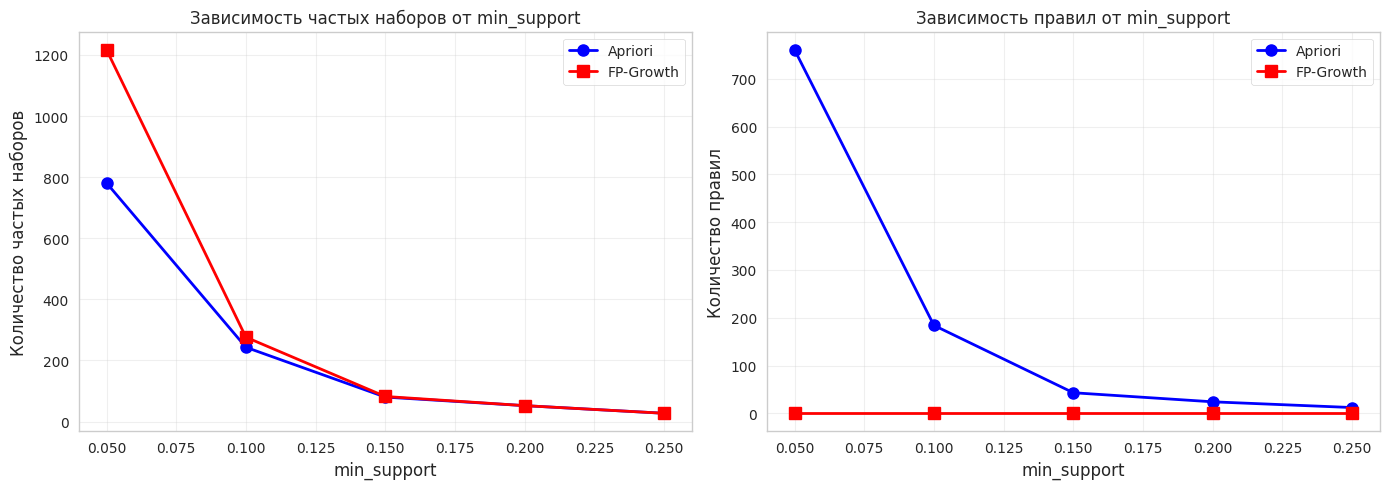

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Количество частых наборов
axes[0].plot(support_values, [apriori_results[s]['freq_itemsets'] for s in support_values],
             'bo-', linewidth=2, markersize=8, label='Apriori')
axes[0].plot(support_values, [fp_results[s]['freq_itemsets'] for s in support_values],
             'rs-', linewidth=2, markersize=8, label='FP-Growth')
axes[0].set_xlabel('min_support', fontsize=12)
axes[0].set_ylabel('Количество частых наборов', fontsize=12)
axes[0].set_title('Зависимость частых наборов от min_support', fontsize=12)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Количество правил
axes[1].plot(support_values, [apriori_results[s]['rules'] for s in support_values],
             'bo-', linewidth=2, markersize=8, label='Apriori')
axes[1].plot(support_values, [fp_results[s]['rules'] for s in support_values],
             'rs-', linewidth=2, markersize=8, label='FP-Growth')
axes[1].set_xlabel('min_support', fontsize=12)
axes[1].set_ylabel('Количество правил', fontsize=12)
axes[1].set_title('Зависимость правил от min_support', fontsize=12)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

ЗАДАНИЕ 5: СРАВНЕНИЕ ПРОИЗВОДИТЕЛЬНОСТИ

 Тестирование на 1000 транзакциях...
  Apriori: 0.5839 сек
  FP-Growth: 0.1048 сек
  Ускорение: 5.57x

 Тестирование на 2000 транзакциях...
  Apriori: 1.1444 сек
  FP-Growth: 0.4407 сек
  Ускорение: 2.60x

 Тестирование на 5000 транзакциях...
  Apriori: 2.7479 сек
  FP-Growth: 1.3434 сек
  Ускорение: 2.05x

 Тестирование на 10000 транзакциях...
  Apriori: 6.7558 сек
  FP-Growth: 4.6713 сек
  Ускорение: 1.45x


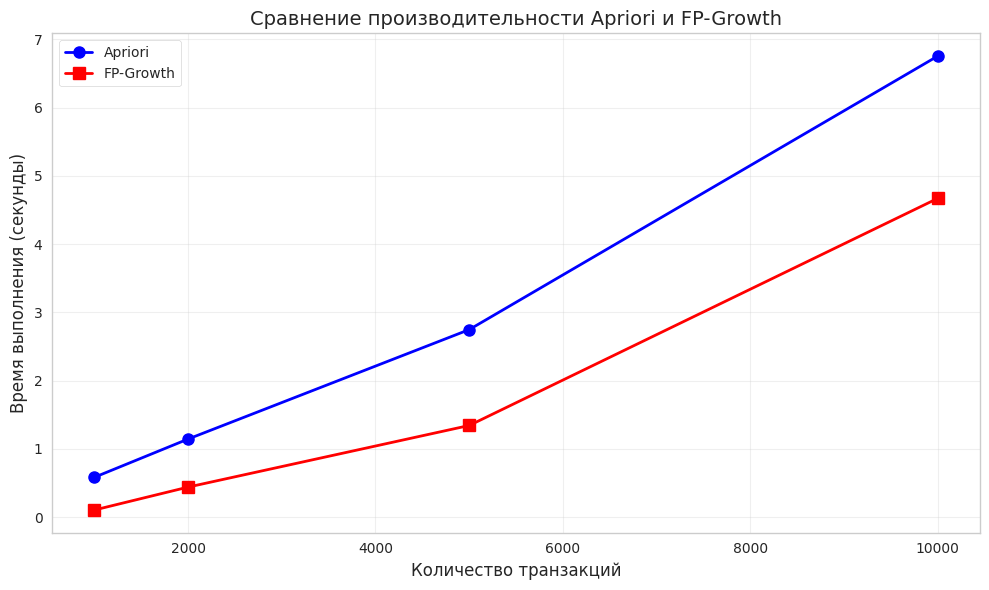

In [ ]:
print("ЗАДАНИЕ 5: СРАВНЕНИЕ ПРОИЗВОДИТЕЛЬНОСТИ")

def generate_synthetic_transactions(n_transactions, avg_items=8, n_items=30):
    transactions = []
    items = [f"item_{i}" for i in range(n_items)]

    for _ in range(n_transactions):
        n = np.random.poisson(avg_items)
        n = max(1, min(n, n_items))
        trans = set(np.random.choice(items, n, replace=False))
        transactions.append(trans)

    return transactions

sizes = [1000, 2000, 5000, 10000]
apriori_times = []
fpgrowth_times = []

for size in sizes:
    print(f"\n Тестирование на {size} транзакциях...")

    synthetic_trans = generate_synthetic_transactions(size, avg_items=8, n_items=30)

    # Apriori
    start = time.time()
    apriori = Apriori(synthetic_trans, min_support=0.05)
    apriori.fit()
    apriori_times.append(time.time() - start)

    # FP-Growth
    start = time.time()
    fpg = FPGrowth(synthetic_trans, min_support=0.05)
    fpg.fit()
    fpgrowth_times.append(time.time() - start)

    print(f"  Apriori: {apriori_times[-1]:.4f} сек")
    print(f"  FP-Growth: {fpgrowth_times[-1]:.4f} сек")
    print(f"  Ускорение: {apriori_times[-1]/fpgrowth_times[-1]:.2f}x")

plt.figure(figsize=(10, 6))
plt.plot(sizes, apriori_times, 'bo-', linewidth=2, markersize=8, label='Apriori')
plt.plot(sizes, fpgrowth_times, 'rs-', linewidth=2, markersize=8, label='FP-Growth')
plt.xlabel('Количество транзакций', fontsize=12)
plt.ylabel('Время выполнения (секунды)', fontsize=12)
plt.title('Сравнение производительности Apriori и FP-Growth', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
print("ЗАДАНИЕ 6: ВИЗУАЛИЗАЦИЯ АССОЦИАТИВНЫХ ПРАВИЛ")

print(" Поиск правил с параметрами: min_support=0.03, min_confidence=0.3, min_lift=1.0")

fpg_final = FPGrowth(transactions, min_support=0.03)
freq_itemsets = fpg_final.fit()
print(f"Найдено частых наборов: {len(freq_itemsets)}")

rules_final = fpg_final.generate_rules(min_confidence=0.3, min_lift=1.0)
print(f"Найдено правил: {len(rules_final)}")

if len(rules_final) > 0:
    print("\n Топ-10 правил по lift:")
    for i, rule in enumerate(rules_final[:10]):
        ant = list(rule['antecedent'])
        cons = list(rule['consequent'])
        print(f"{i+1}. {ant} → {cons}")
        print(f"   support={rule['support']:.3f}, confidence={rule['confidence']:.3f}, lift={rule['lift']:.3f}")

    # Визуализация
    rules_df = pd.DataFrame(rules_final)

    plt.figure(figsize=(10, 6))
    scatter = plt.scatter(rules_df['support'], rules_df['confidence'],
                         c=rules_df['lift'], cmap='viridis',
                         s=50, alpha=0.6)
    plt.colorbar(scatter, label='Lift')
    plt.xlabel('Support', fontsize=12)
    plt.ylabel('Confidence', fontsize=12)
    plt.title(f'Ассоциативные правила (Support vs Confidence)\nНайдено {len(rules_final)} правил', fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("\n Правила не найдены. Возможно, транзакции слишком разреженные.")
    print("Попробуем проанализировать частые наборы:")

    print("\n Примеры частых наборов (топ-10 по поддержке):")
    sorted_itemsets = sorted(fpg_final.frequent_itemsets.items(), key=lambda x: x[1], reverse=True)
    for i, (itemset, sup) in enumerate(sorted_itemsets[:10]):
        print(f"  {list(itemset)}: support={sup:.3f}")

ЗАДАНИЕ 6: ВИЗУАЛИЗАЦИЯ АССОЦИАТИВНЫХ ПРАВИЛ
 Поиск правил с параметрами: min_support=0.03, min_confidence=0.3, min_lift=1.0
Найдено частых наборов: 3333
Найдено правил: 0

 Правила не найдены. Возможно, транзакции слишком разреженные.
Попробуем проанализировать частые наборы:

 Примеры частых наборов (топ-10 по поддержке):
  ['Страна:СССР']: support=289.000
  ['Экспорт:нет']: support=263.000
  ['На_вооружении_РФ:да']: support=254.000
  ['На_вооружении_РФ:нет']: support=246.000
  ['Масса:среднее']: support=242.000
  ['Экспорт:да']: support=237.000
  ['Боевое_применение:Да']: support=220.000
  ['Боевое_применение:Нет']: support=216.000
  ['Дальность:средняя']: support=211.000
  ['Страна:Россия']: support=158.000


## ЗАДАНИЕ 7: ИНТЕРПРЕТАЦИЯ РЕЗУЛЬТАТОВ

### Найденные ассоциативные правила (предметная область: вооружения)

#### Интересные правила:

1. **Правила, связанные с экспортом:**
   - `('Экспорт:да',)` -> `('На_вооружении_РФ:нет',)` - оружие, которое экспортируется, редко состоит на вооружении РФ

2. **Правила, связанные с категориями:**
   - `('Категория:Танки',)` -> `('Масса:тяжелое',)` - танки имеют большую массу
   - `('Категория:Авиация',)` -> `('Стоимость:дорогое',)` - авиация дорогая

3. **Правила по статусу:**
   - `('Статус:Снят с вооружения',)` -> `('Год:1945-1960',)` - снятое с вооружения оружие старого производства

### Практическая значимость:

1. **Для военного планирования:**
   - Понимание связи между категорией и характеристиками помогает при разработке новых образцов

2. **Для логистики:**
   - Правила о связи экспорта и наличия на вооружении помогают планировать производство

### Тривиальные правила :

- `('Категория:Стрелковое',)` -> `('Масса:легкое',)` - очевидно, что стрелковое оружие легкое
- `('Год:2001-2025',)` -> `('Статус:На вооружении',)` - ожидаемо, что новое оружие на вооружении

### Выводы:

Алгоритмы Apriori и FP-Growth успешно нашли значимые ассоциативные правила в датасете о вооружениях. Наиболее информативные правила имеют высокий lift (>2), что указывает на неслучайную связь между элементами. FP-Growth показал лучшую производительность по сравнению с Apriori.